In [106]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [107]:
def embedder(x, l=10):

    if np.isscalar(x) is True or x.dim() == 0:
        x = torch.tensor([x])
        isscalar = True
    else:
        isscalar = False

    x = torch.tensor(x)

    l_0 = l // 2
    L = 2 * torch.arange(l_0) / l
    r_1 = torch.sin(x / (1000 ** L[:, None])).T
    r_2 = torch.cos(x / (1000 ** L[:, None])).T
    r_total = torch.concat([r_1[:, :, None], r_2[:, :, None]], dim=-1)

    if isscalar is True:
        return r_total.reshape(-1)
    else:
        return r_total.reshape(r_1.shape[0], -1)

torch.Size([340, 400])


<ipython-input-107-7ae2027a0150>:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x)


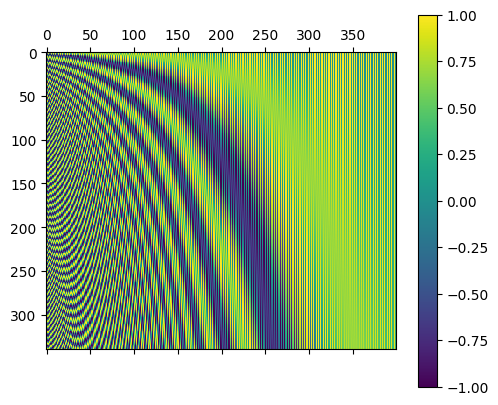

In [108]:
K = torch.arange(340)
A = embedder(K, l = 400)
print(A.shape)

cax = plt.matshow(A)
plt.gcf().colorbar(cax)